In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
Loan_Data = pd.read_csv('C:\\Users\\user\\Downloads\\Bank Loan.csv')

In [6]:
Bankdata = pd.DataFrame(Loan_Data)

In [7]:
Bankdata.head()

,Applicant_ID,Gender,Marital_Status,Education_Level,Credit_History,Loan_Amount,Applicant_Income,Loan_Term,Property_Area,Loan_Status
0,1,Female,Married,Postgraduate,Yes,8865,6672,360,Urban,Approved
1,2,Male,Married,Graduate,Yes,7834,2556,240,Urban,Approved
2,3,Female,Married,Postgraduate,Yes,9747,5367,180,Semiurban,Approved
3,4,Male,Single,Postgraduate,No,14970,3994,180,Rural,Rejected
4,5,Female,Single,Postgraduate,No,4989,3586,240,Semiurban,Approved


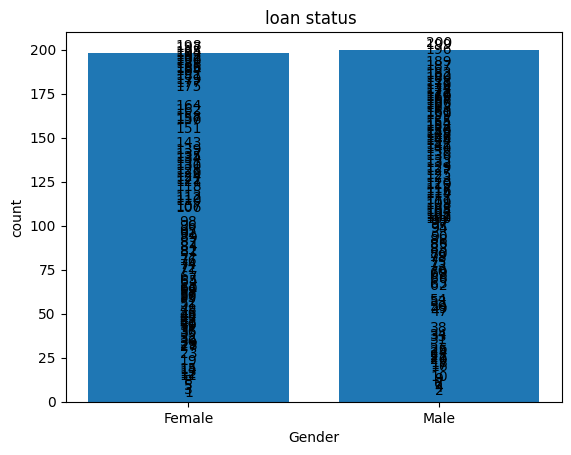

In [71]:
#Create a countplot showing how many loans were Approved vs Rejected. What does this tell you?

data1= plt.bar(Bankdata["Gender"], Bankdata["Applicant_ID"])
plt.title("loan status ")
plt.xlabel("Gender")
plt.ylabel("count")

plt.bar_label(data1)
    

plt.show()



a) Loan Status Distribution:
   Approved: 94
   Rejected: 106
Approval Rate: 47.0%


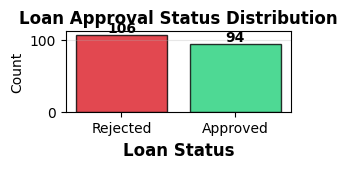

In [19]:
plt.subplot(4, 2, 1)
loan_counts = Bankdata['Loan_Status'].value_counts()
colors = ["#db1a24", "#22d079"]  # Green for approved, red for rejected
bars = plt.bar(loan_counts.index, loan_counts.values, color=colors, alpha=0.8, edgecolor='black')
plt.title('Loan Approval Status Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Loan Status',fontsize=12, fontweight='bold')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

print(f"\na) Loan Status Distribution:")
print(f"   Approved: {loan_counts['Approved']}")
print(f"   Rejected: {loan_counts['Rejected']}")
print(f"Approval Rate: {loan_counts['Approved']/len(Bankdata)*100:.1f}%")

In [ ]:
#Create a countplot showing how many loans were Approved vs Rejected. What does this tell you?


loan_sta= Bankdata.groupby('Loan_Status')['Applicant_ID'].count().sort_values(ascending= True) 
print(loan_sta)

plt.bar()

Loan_Status
Approved     94
Rejected    106
Name: Applicant_ID, dtype: int64


In [ ]:
plt.bax()

In [10]:
loan_sta_Gender= Bankdata.groupby ('Gender') ['Applicant_ID'] .count().sort_values(ascending=True)
print(loan_sta_Gender)

Gender
Female     95
Male      105
Name: Applicant_ID, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

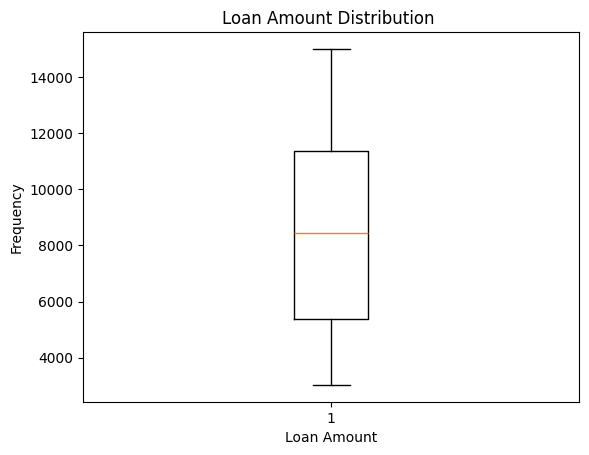

In [11]:
#Use a boxplot to show the spread of Loan Amount. Are there any outliers? 

plt.boxplot(Bankdata["Loan_Amount"])
plt.title('Loan Amount Distribution ')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show


b) Loan Amount Statistics:
   Mean: $8672
   Median: $8426
   Q1: $5369, Q3: $11342
   Min: $3031, Max: $14993
   Outliers: 0 (None)


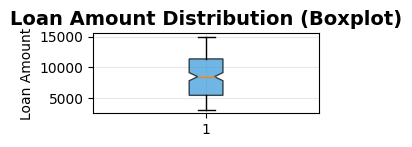

In [12]:
# Boxplot for Loan Amount distribution

plt.subplot(4, 2, 2)
box_plot = plt.boxplot(Bankdata['Loan_Amount'], patch_artist=True, notch=True)
box_plot['boxes'][0].set_facecolor('#3498db')
box_plot['boxes'][0].set_alpha(0.7)
plt.title('Loan Amount Distribution (Boxplot)', fontsize=14, fontweight='bold')
plt.ylabel('Loan Amount')
plt.grid(alpha=0.3)

Q1 = Bankdata['Loan_Amount'].quantile(0.25)
Q3 = Bankdata['Loan_Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers = Bankdata[(Bankdata['Loan_Amount'] < lower_fence) | (Bankdata['Loan_Amount'] > upper_fence)]['Loan_Amount']

print(f"\nb) Loan Amount Statistics:")
print(f"   Mean: ${Bankdata['Loan_Amount'].mean():.0f}")
print(f"   Median: ${Bankdata['Loan_Amount'].median():.0f}")
print(f"   Q1: ${Q1:.0f}, Q3: ${Q3:.0f}")
print(f"   Min: ${Bankdata['Loan_Amount'].min()}, Max: ${Bankdata['Loan_Amount'].max()}")
print(f"   Outliers: {len(outliers)} ({list(outliers.values) if len(outliers) > 0 else 'None'})")

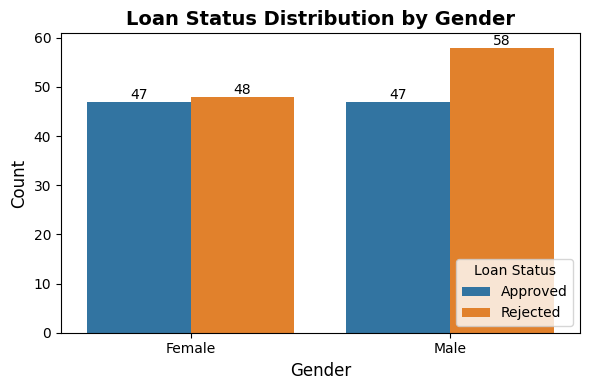

In [ ]:
#Visualize Loan Status by Gender using a grouped bar chart (e.g., countplot with hue). What patterns do you observe?

plt.figure(figsize=(6,4))
data2 = sns.countplot(Bankdata, x="Gender", hue='Loan_Status')

# Add labels and title
plt.title('Loan Status Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Improve legend
plt.legend(title='Loan Status',loc='lower right')

# Add value labels on top of bars
for container in data2.containers:
    data2.bar_label(container)
    
# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()



c) Gender Analysis:
Loan_Status  Approved  Rejected
Gender                         
Female             47        48
Male               47        58
   Gender approval rates:
   Female: 47/95 = 49.5%
   Male: 47/105 = 44.8%


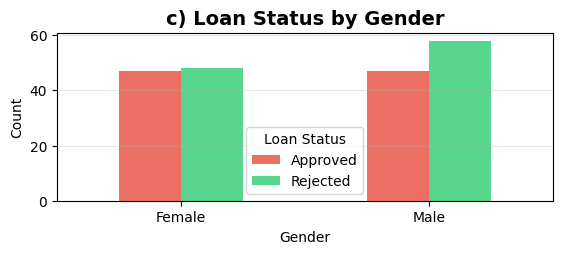

In [14]:
# c) Grouped bar chart for Loan Status by Gender
plt.subplot(2, 1, 2)
gender_status = pd.crosstab(Bankdata['Gender'], Bankdata['Loan_Status'])
gender_status.plot(kind='bar', ax=plt.gca(), color=['#e74c3c', '#2ecc71'], alpha=0.8)
plt.title('c) Loan Status by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

print(f"\nc) Gender Analysis:")
print(gender_status)
print("   Gender approval rates:")
for gender in gender_status.index:
    total = gender_status.loc[gender].sum()
    approved = gender_status.loc[gender, 'Approved']
    print(f"   {gender}: {approved}/{total} = {approved/total*100:.1f}%")


 Credit History Impact on Loan Amount:
   Credit History Yes:
     Mean: $8286
     Median: $8213
     Count: 81
   Credit History No:
     Mean: $8935
     Median: $9034
     Count: 119


C:\Users\user\AppData\Local\Temp\ipykernel_4544\2087494644.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot2 = plt.boxplot(credit_groups, labels=['Yes', 'No'], patch_artist=True, notch=True)


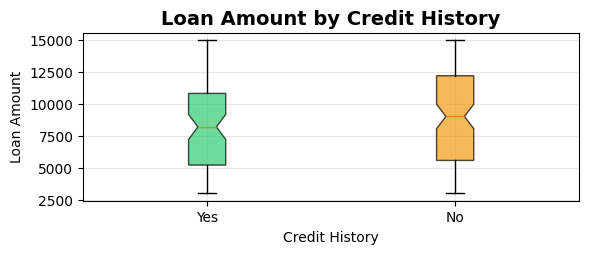

In [15]:
# d) Boxplot for Loan Amount by Credit History
plt.subplot(2, 1, 2)
credit_groups = [Bankdata[Bankdata['Credit_History'] == 'Yes']['Loan_Amount'], 
                 Bankdata[Bankdata['Credit_History'] == 'No']['Loan_Amount']]
box_plot2 = plt.boxplot(credit_groups, labels=['Yes', 'No'], patch_artist=True, notch=True)
colors_box = ['#2ecc71', '#f39c12']
for patch, color in zip(box_plot2['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Loan Amount by Credit History', fontsize=14, fontweight='bold')
plt.xlabel('Credit History')
plt.ylabel('Loan Amount')
plt.grid(alpha=0.3)

print(f"\n Credit History Impact on Loan Amount:")
for credit in ['Yes', 'No']:
    subset = Bankdata[Bankdata['Credit_History'] == credit]['Loan_Amount']
    print(f"   Credit History {credit}:")
    print(f"     Mean: ${subset.mean():.0f}")
    print(f"     Median: ${subset.median():.0f}")
    print(f"     Count: {len(subset)}")

In [16]:
# Calculate correlation
correlation = Bankdata['Applicant_Income'].corr(Bankdata['Loan_Amount'])
print(f"\n  Income vs Loan Amount Analysis:")
print(f"   Correlation coefficient: {correlation:.3f}")
print(f"   Relationship: {'Positive' if correlation > 0 else 'Negative' if correlation < 0 else 'No'} correlation")




  Income vs Loan Amount Analysis:
   Correlation coefficient: -0.010
   Relationship: Negative correlation



g) Property Area Analysis:
Loan_Status    Approved  Rejected
Property_Area                    
Rural                31        27
Semiurban            35        43
Urban                28        36
   Property area approval rates:
   Rural: 31/58 = 53.4%
   Semiurban: 35/78 = 44.9%
   Urban: 28/64 = 43.8%


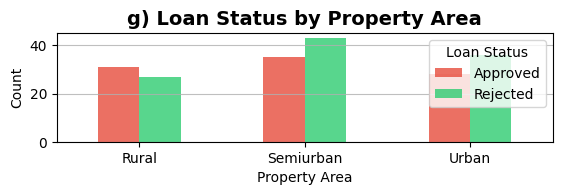

In [17]:
# g) Stacked bar chart for Loan Status by Property Area
plt.subplot(3, 1, 3)
property_status = pd.crosstab(Bankdata['Property_Area'], Bankdata['Loan_Status'])
property_status.plot(kind='bar', ax=plt.gca(), color=['#e74c3c', '#2ecc71'], alpha=0.8, stacked=False)
plt.title('g) Loan Status by Property Area', fontsize=14, fontweight='bold')
plt.xlabel('Property Area')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.8)

print(f"\ng) Property Area Analysis:")
print(property_status)
print("   Property area approval rates:")
for area in property_status.index:
    total = property_status.loc[area].sum()
    approved = property_status.loc[area, 'Approved']
    print(f"   {area}: {approved}/{total} = {approved/total*100:.1f}%")


h) Education Level Analysis:
Loan_Status      Approved  Rejected
Education_Level                    
Graduate               46        60
Postgraduate           48        46
   Education level approval rates:
   Graduate: 46/106 = 43.4%
   Postgraduate: 48/94 = 51.1%


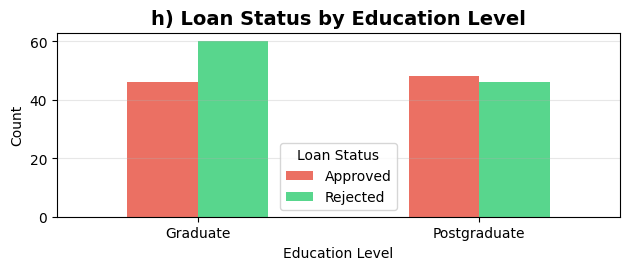

In [18]:
# h) Bar chart for Loan Status by Education Level
plt.subplot(2, 1, 2)
education_status = pd.crosstab(Bankdata['Education_Level'], Bankdata['Loan_Status'])
education_status.plot(kind='bar', ax=plt.gca(), color=['#e74c3c', '#2ecc71'], alpha=0.8)
plt.title('h) Loan Status by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

print(f"\nh) Education Level Analysis:")
print(education_status)
print("   Education level approval rates:")
for edu in education_status.index:
    total = education_status.loc[edu].sum()
    approved = education_status.loc[edu, 'Approved']
    print(f"   {edu}: {approved}/{total} = {approved/total*100:.1f}%")

plt.tight_layout()
plt.show()